# Visualization

# Dataset Visualization

In [47]:
from pathlib import Path
import pandas as pd

business_path = next(
    Path(".").rglob(
        "new_orleans_food_hospitality_businesses.csv"
    )
)

print("Using:", business_path)

businesses = pd.read_csv(business_path)

print("Shape:", businesses.shape)

Using: processed_data copy/new_orleans_subset/_archive_before_final_preparation/new_orleans_food_hospitality_businesses.csv
Shape: (3505, 20)


In [55]:
from pathlib import Path

matches = list(
    Path(".").rglob(
        "new_orleans_food_hospitality_businesses.csv"
    )
)

for i, path in enumerate(matches, start=1):
    print(i, path)

1 processed_data copy/new_orleans_subset/_archive_before_final_preparation/new_orleans_food_hospitality_businesses.csv
2 processed_data/new_orleans_subset/_archive_before_final_preparation/new_orleans_food_hospitality_businesses.csv


In [59]:
from pathlib import Path
import pandas as pd

subset_root = Path("processed_data copy/new_orleans_subset")

candidates = []

for path in subset_root.rglob("*.csv"):
    # Ignore archived copies for now
    if "_archive" in str(path).lower():
        continue

    try:
        sample = pd.read_csv(path, nrows=5)

        # Look for the columns we expect in the business catalogue
        expected = {
            "business_id",
            "categories"
        }

        if expected.issubset(sample.columns):
            candidates.append(
                {
                    "path": path,
                    "columns": sample.columns.tolist()
                }
            )

    except Exception:
        pass

print(f"Found {len(candidates)} possible business files:\n")

for i, item in enumerate(candidates, start=1):
    print(f"{i}. {item['path']}")
    print("   Columns:", item["columns"])
    print()

Found 0 possible business files:



In [57]:
businesses[
    ["business_id", "categories", "matched_target_categories"]
].head()

,business_id,categories,matched_target_categories
0,w_AMNoI1iG9eay7ncmc67w,"Event Planning & Services, Hotels, Hotels & Tr...","[""Hotels""]"
1,YNjyv0gfOr2g8lbmUpTnKg,"Nightlife, Pubs, Event Planning & Services, Wi...","[""Bars"", ""Nightlife"", ""Pubs"", ""Restaurants"", ""..."
2,J_ksUDPpzPwfTGtI4zTRnQ,"Event Planning & Services, Caterers, Party & E...","[""Caterers""]"
3,TLZ3-eDPLhUzfsWO4ad6Ug,"Restaurants, Seafood, Cajun/Creole","[""Restaurants""]"
4,FRYkg_JvsWU9xIXZsEZcVA,"Cocktail Bars, Italian, Nightlife, Seafood, Ba...","[""Bars"", ""Cocktail Bars"", ""Nightlife"", ""Restau..."


In [61]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# Dissertation visualisation theme
TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"

# --------------------------------------------------
# Parse matched target categories
# --------------------------------------------------

def parse_categories(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else [parsed]
    except (ValueError, SyntaxError):
        return []


category_series = (
    businesses["matched_target_categories"]
    .apply(parse_categories)
    .explode()
    .dropna()
)

# Count businesses represented by each target category
category_distribution = (
    category_series
    .value_counts()
    .rename_axis("category")
    .reset_index(name="businesses")
)

# Percentage of the full 3,505-business catalogue
category_distribution["percentage"] = (
    category_distribution["businesses"]
    / len(businesses)
    * 100
)

category_distribution.head(15)

,category,businesses,percentage
0,Restaurants,2261,64.507846
1,Food,1263,36.034237
2,Nightlife,942,26.875892
3,Bars,826,23.566334
4,Coffee & Tea,318,9.072753
5,Hotels,296,8.445078
6,Specialty Food,213,6.077033
7,Cocktail Bars,203,5.791726
8,Venues & Event Spaces,200,5.706134
9,Cafes,173,4.935806


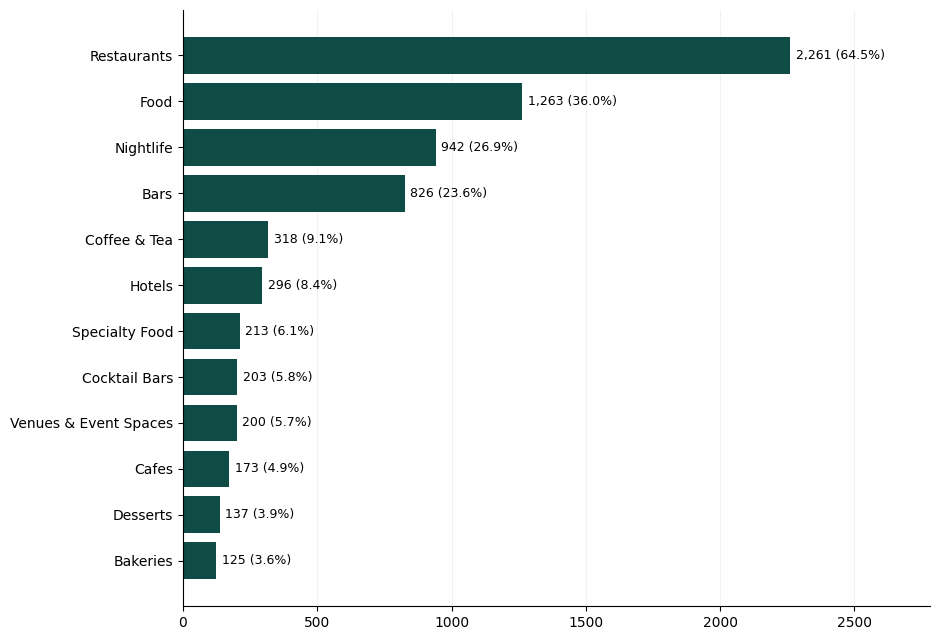

In [63]:
# --------------------------------------------------
# Plot the 12 most prevalent target categories
# --------------------------------------------------

plot_data = (
    category_distribution
    .head(12)
    .sort_values("businesses", ascending=True)
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

bars = ax.barh(
    plot_data["category"],
    plot_data["businesses"],
    color=TEAL
)

# Count + catalogue-share labels
for bar, count, pct in zip(
    bars,
    plot_data["businesses"],
    plot_data["percentage"]
):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({pct:.1f}%)",
        va="center",
        fontsize=9
    )

# ax.set_xlabel("Number of businesses", fontsize=10)
# ax.set_ylabel("Target business category", fontsize=10)

# ax.set_title(
#     "Distribution of Target Business Categories\n"
#     "in the New Orleans Discovery Catalogue",
#     fontsize=12,
#     weight="bold",
#     pad=12
# )

# Space for value labels
ax.set_xlim(
    0,
    plot_data["businesses"].max() * 1.23
)

# Dissertation-friendly styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.7
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "new_orleans_target_business_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
import pandas as pd

personalisation_candidates = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and "business_id" in obj.columns:
        n_businesses = obj["business_id"].nunique()

        if n_businesses == 2516:
            personalisation_candidates.append((name, obj.shape, obj.columns.tolist()))

print("DataFrames containing exactly 2,516 unique businesses:\n")

for name, shape, columns in personalisation_candidates:
    print(f"{name}: {shape}")
    print(columns)
    print()

DataFrames containing exactly 2,516 unique businesses:



In [67]:
photo_candidates = []

for name, obj in list(globals().items()):
    if (
        isinstance(obj, pd.DataFrame)
        and {"photo_id", "business_id", "label"}.issubset(obj.columns)
    ):
        photo_candidates.append(
            (
                name,
                obj.shape,
                obj["photo_id"].nunique(),
                obj["business_id"].nunique()
            )
        )

print("Possible photo DataFrames:\n")

for item in photo_candidates:
    print(item)

Possible photo DataFrames:



In [69]:
import matplotlib.pyplot as plt
import pandas as pd

TEAL = "#0F4C45"

plot_data = diversity_distribution.copy()

label_map = {
    0: "0\n(No visual\n evidence)",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5"
}

plot_data["label_group"] = plot_data["unique_visual_labels"].map(label_map)

fig, ax = plt.subplots(figsize=(9, 5.6))

bars = ax.bar(
    plot_data["label_group"],
    plot_data["businesses"],
    color=TEAL
)

for bar, count, pct in zip(
    bars,
    plot_data["businesses"],
    plot_data["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xlabel("Distinct Yelp visual labels per business")
ax.set_ylabel("Number of businesses")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("visual_label_diversity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'diversity_distribution' is not defined

# Research Question

In [1]:
import pandas as pd

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# --------------------------------------------------
# Visualisation paths
# --------------------------------------------------

# Use the existing processed_data_root if this notebook already has it.
# Otherwise locate the processed_data folder relative to the notebook.
if "processed_data_root" not in globals():

    possible_processed_paths = [
        Path.cwd() / "processed_data",
        Path.cwd().parent / "processed_data",
        Path.cwd().parent.parent / "processed_data"
    ]

    matching_paths = [
        path
        for path in possible_processed_paths
        if path.exists()
    ]

    if len(matching_paths) == 0:
        raise FileNotFoundError(
            "Could not locate the processed_data folder. "
            "Check the notebook working directory with Path.cwd()."
        )

    processed_data_root = matching_paths[0]


final_model_dir = (
    processed_data_root
    /
    "new_orleans_model_outputs"
)


figure_dir = (
    final_model_dir
    /
    "figures"
)


figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Processed data:",
    processed_data_root.resolve()
)

print(
    "Model outputs:",
    final_model_dir.resolve()
)

print(
    "Figures:",
    figure_dir.resolve()
)

Processed data: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data
Model outputs: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data/new_orleans_model_outputs
Figures: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data/new_orleans_model_outputs/figures


In [3]:
# --------------------------------------------------
# Dissertation figure styling
# --------------------------------------------------

TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


def add_bar_value_labels(
    ax,
    fmt="{:.4f}",
    padding=3,
    fontsize=9
):
    for container in ax.containers:

        labels = [
            fmt.format(
                bar.get_height()
            )
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=fontsize
        )

In [4]:
final_test_comparison = pd.read_csv(
    final_model_dir
    /
    "final_test_metrics.csv",

    index_col=0
)


final_nv_test_metrics = (
    final_test_comparison[
        "KGRec-NV"
    ]
    .to_dict()
)


final_mm_test_metrics = (
    final_test_comparison[
        "KGRec-MM"
    ]
    .to_dict()
)

In [5]:
paired_bootstrap_summary = pd.read_csv(
    final_model_dir
    /
    "paired_test_bootstrap_summary.csv"
)

In [6]:
mm_visual_perturbation_metrics = pd.read_csv(
    final_model_dir
    /
    "rq3_mm_visual_perturbation_metrics.csv",

    index_col=0
)

In [7]:
# --------------------------------------------------
# Load frozen final test results for visualisation
# --------------------------------------------------

final_test_comparison = pd.read_csv(
    final_model_dir
    /
    "final_test_metrics.csv",

    index_col=0
)


final_nv_test_metrics = (
    final_test_comparison[
        "KGRec-NV"
    ]
    .to_dict()
)


final_mm_test_metrics = (
    final_test_comparison[
        "KGRec-MM"
    ]
    .to_dict()
)


print("Final test metrics loaded successfully.")

display(
    final_test_comparison
)

Final test metrics loaded successfully.


,KGRec-NV,KGRec-MM
Recall@5,0.040424,0.041692
NDCG@5,0.026427,0.026689
MAP@5,0.021831,0.021785
Recall@10,0.064305,0.067574
NDCG@10,0.034106,0.034965
MAP@10,0.024975,0.025146
Recall@20,0.100861,0.111000
NDCG@20,0.043217,0.045860
MAP@20,0.027407,0.028093
MeanRank,485.083050,492.093456


In [8]:
print(
    "NV Recall@5:",
    final_nv_test_metrics[
        "Recall@5"
    ]
)

print(
    "MM Recall@5:",
    final_mm_test_metrics[
        "Recall@5"
    ]
)

NV Recall@5: 0.0404242545527316
MM Recall@5: 0.041691681675672


In [9]:
# --------------------------------------------------
# Load all frozen result tables used by figures
# --------------------------------------------------

# Final NV vs MM test metrics
final_test_comparison = pd.read_csv(
    final_model_dir
    /
    "final_test_metrics.csv",
    index_col=0
)

final_nv_test_metrics = (
    final_test_comparison[
        "KGRec-NV"
    ]
    .to_dict()
)

final_mm_test_metrics = (
    final_test_comparison[
        "KGRec-MM"
    ]
    .to_dict()
)


# Paired bootstrap results
paired_bootstrap_summary = pd.read_csv(
    final_model_dir
    /
    "paired_test_bootstrap_summary.csv"
)


# Frozen MM visual perturbation results
mm_visual_perturbation_metrics = pd.read_csv(
    final_model_dir
    /
    "rq3_mm_visual_perturbation_metrics.csv",
    index_col=0
)


# Enriched RQ3 user/test analysis
rq3_analysis = pd.read_parquet(
    final_model_dir
    /
    "rq3_paired_test_analysis.parquet"
)


print(
    "Loaded:",
    "\n- final test metrics",
    "\n- paired bootstrap results",
    "\n- visual perturbation metrics",
    "\n- RQ3 analysis dataset"
)

Loaded: 
- final test metrics 
- paired bootstrap results 
- visual perturbation metrics 
- RQ3 analysis dataset


In [10]:
TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


def add_bar_value_labels(
    ax,
    fmt="{:.4f}",
    padding=3,
    fontsize=9
):
    for container in ax.containers:

        labels = [
            fmt.format(
                bar.get_height()
            )
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=fontsize
        )

In [11]:
def add_bar_value_labels(ax, fmt="{:.4f}", padding=3, fontsize=9):
    for container in ax.containers:
        labels = [
            fmt.format(bar.get_height())
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=fontsize
        )

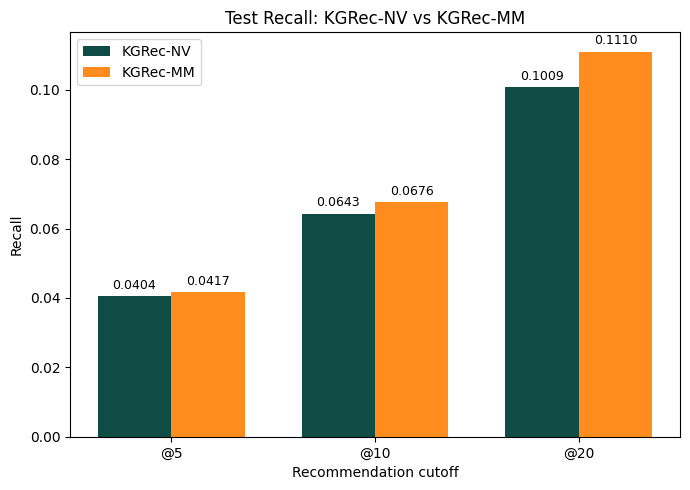

In [12]:
import matplotlib.pyplot as plt
import numpy as np

figure_dir = (
    final_model_dir
    / "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"

def add_bar_value_labels(ax, fmt="{:.4f}", padding=3, fontsize=9):
    for container in ax.containers:
        labels = [
            fmt.format(bar.get_height())
            for bar in container
        ]
        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=fontsize
        )

ks = np.array([5, 10, 20])

nv_recall = np.array([
    final_nv_test_metrics["Recall@5"],
    final_nv_test_metrics["Recall@10"],
    final_nv_test_metrics["Recall@20"]
])

mm_recall = np.array([
    final_mm_test_metrics["Recall@5"],
    final_mm_test_metrics["Recall@10"],
    final_mm_test_metrics["Recall@20"]
])

x = np.arange(len(ks))
width = 0.36

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width / 2,
    nv_recall,
    width,
    label="KGRec-NV",
    color=TEAL
)

ax.bar(
    x + width / 2,
    mm_recall,
    width,
    label="KGRec-MM",
    color=TANGERINE
)

ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in ks])
ax.set_xlabel("Recommendation cutoff")
ax.set_ylabel("Recall")
ax.set_title("Test Recall: KGRec-NV vs KGRec-MM")
ax.legend()

add_bar_value_labels(ax, fmt="{:.4f}")

fig.tight_layout()

fig.savefig(
    figure_dir / "test_recall_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

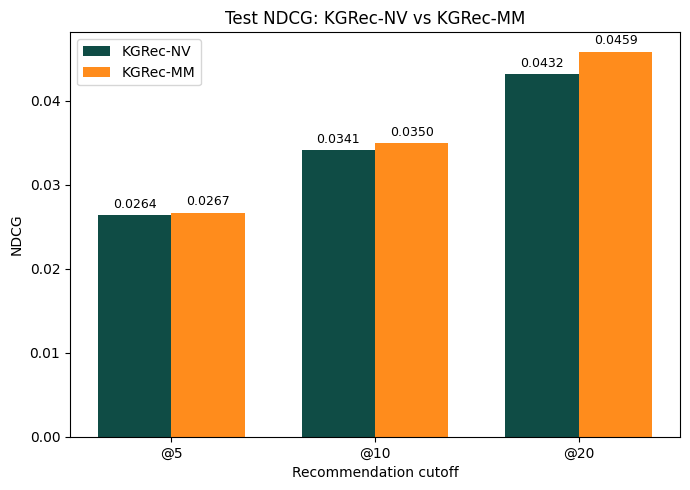

In [13]:
nv_ndcg = np.array([
    final_nv_test_metrics["NDCG@5"],
    final_nv_test_metrics["NDCG@10"],
    final_nv_test_metrics["NDCG@20"]
])

mm_ndcg = np.array([
    final_mm_test_metrics["NDCG@5"],
    final_mm_test_metrics["NDCG@10"],
    final_mm_test_metrics["NDCG@20"]
])

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width / 2,
    nv_ndcg,
    width,
    label="KGRec-NV",
    color=TEAL
)

ax.bar(
    x + width / 2,
    mm_ndcg,
    width,
    label="KGRec-MM",
    color=TANGERINE
)

ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in ks])
ax.set_xlabel("Recommendation cutoff")
ax.set_ylabel("NDCG")
ax.set_title("Test NDCG: KGRec-NV vs KGRec-MM")
ax.legend()

add_bar_value_labels(ax, fmt="{:.4f}")

fig.tight_layout()

fig.savefig(
    figure_dir / "test_ndcg_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

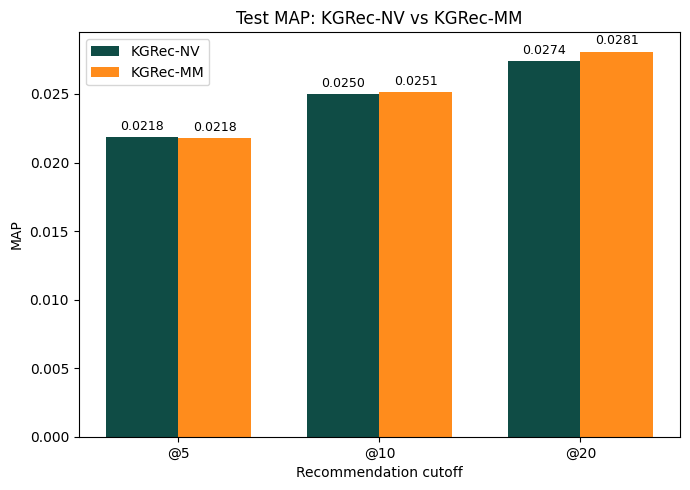

In [14]:
nv_map = np.array([
    final_nv_test_metrics["MAP@5"],
    final_nv_test_metrics["MAP@10"],
    final_nv_test_metrics["MAP@20"]
])

mm_map = np.array([
    final_mm_test_metrics["MAP@5"],
    final_mm_test_metrics["MAP@10"],
    final_mm_test_metrics["MAP@20"]
])

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width / 2,
    nv_map,
    width,
    label="KGRec-NV",
    color=TEAL
)

ax.bar(
    x + width / 2,
    mm_map,
    width,
    label="KGRec-MM",
    color=TANGERINE
)

ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in ks])
ax.set_xlabel("Recommendation cutoff")
ax.set_ylabel("MAP")
ax.set_title("Test MAP: KGRec-NV vs KGRec-MM")
ax.legend()

add_bar_value_labels(ax, fmt="{:.4f}")

fig.tight_layout()

fig.savefig(
    figure_dir / "test_map_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

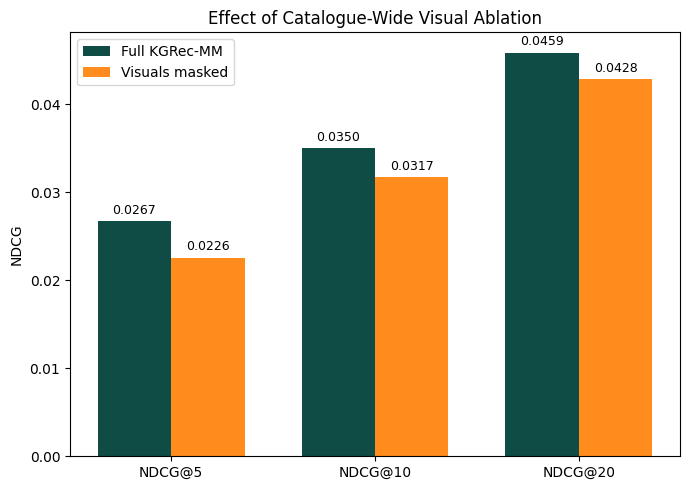

In [15]:
ablation_metrics = [
    "NDCG@5",
    "NDCG@10",
    "NDCG@20"
]

full_mm_values = (
    mm_visual_perturbation_metrics
    .loc[ablation_metrics, "Full MM"]
    .to_numpy()
)

all_off_values = (
    mm_visual_perturbation_metrics
    .loc[ablation_metrics, "All visuals masked"]
    .to_numpy()
)

x = np.arange(len(ablation_metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width / 2,
    full_mm_values,
    width,
    label="Full KGRec-MM",
    color=TEAL
)

ax.bar(
    x + width / 2,
    all_off_values,
    width,
    label="Visuals masked",
    color=TANGERINE
)

ax.set_xticks(x)
ax.set_xticklabels(ablation_metrics)
ax.set_ylabel("NDCG")
ax.set_title("Effect of Catalogue-Wide Visual Ablation")
ax.legend()

add_bar_value_labels(ax, fmt="{:.4f}")

fig.tight_layout()

fig.savefig(
    figure_dir / "mm_visual_ablation_ndcg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

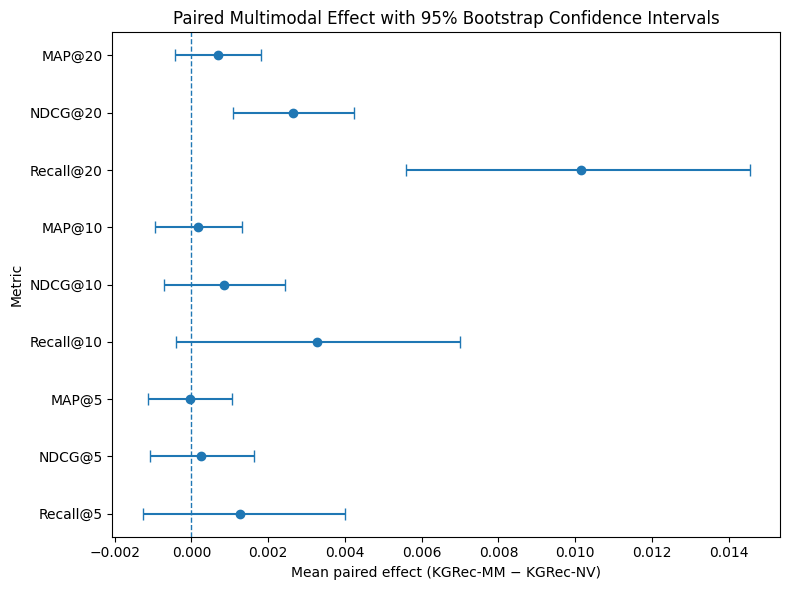

In [16]:
plot_bootstrap = (
    paired_bootstrap_summary
    .copy()
)


metric_order = [
    "Recall@5",
    "NDCG@5",
    "MAP@5",
    "Recall@10",
    "NDCG@10",
    "MAP@10",
    "Recall@20",
    "NDCG@20",
    "MAP@20"
]


plot_bootstrap[
    "metric"
] = pd.Categorical(
    plot_bootstrap[
        "metric"
    ],
    categories=metric_order,
    ordered=True
)


plot_bootstrap = (
    plot_bootstrap
    .sort_values(
        "metric"
    )
)


y = np.arange(
    len(
        plot_bootstrap
    )
)


effects = (
    plot_bootstrap[
        "MM_minus_NV"
    ]
    .to_numpy()
)


lower_errors = (
    effects
    -
    plot_bootstrap[
        "CI_95_lower"
    ].to_numpy()
)


upper_errors = (
    plot_bootstrap[
        "CI_95_upper"
    ].to_numpy()
    -
    effects
)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.errorbar(
    effects,
    y,
    xerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=4
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot_bootstrap[
        "metric"
    ]
)


ax.set_xlabel(
    "Mean paired effect (KGRec-MM − KGRec-NV)"
)

ax.set_ylabel(
    "Metric"
)

ax.set_title(
    "Paired Multimodal Effect with 95% Bootstrap Confidence Intervals"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "paired_mm_effect_bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# --------------------------------------------------
# Recreate visual-supported RQ3 subset
# --------------------------------------------------

visual_cases = (
    rq3_analysis[
        rq3_analysis[
            "target_has_visual"
        ].astype(bool)
    ]
    .copy()
)


print(
    "Visual-supported test cases:",
    len(visual_cases)
)

print(
    "Raw image-count column available:",
    "eligible_image_count_raw"
    in visual_cases.columns
)

Visual-supported test cases: 13266
Raw image-count column available: True


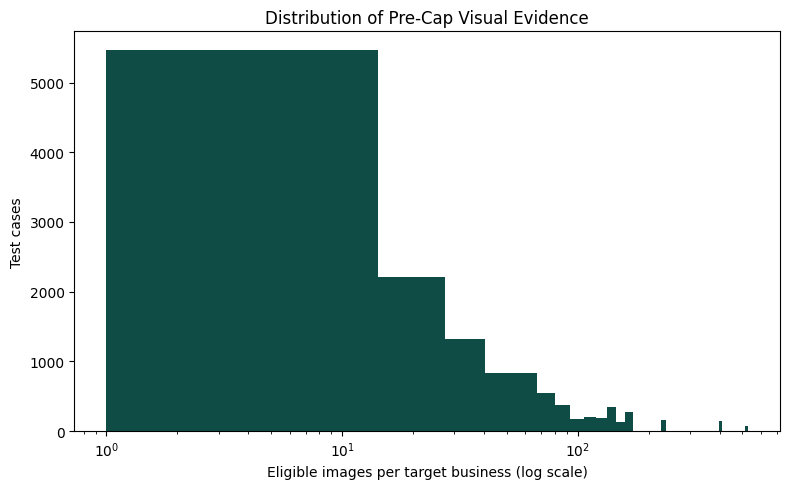

In [18]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    visual_cases[
        "eligible_image_count_raw"
    ],
    bins=40,
    color=TEAL
)


ax.set_xscale(
    "log"
)


ax.set_xlabel(
    "Eligible images per target business (log scale)"
)

ax.set_ylabel(
    "Test cases"
)

ax.set_title(
    "Distribution of Pre-Cap Visual Evidence"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "raw_visual_evidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

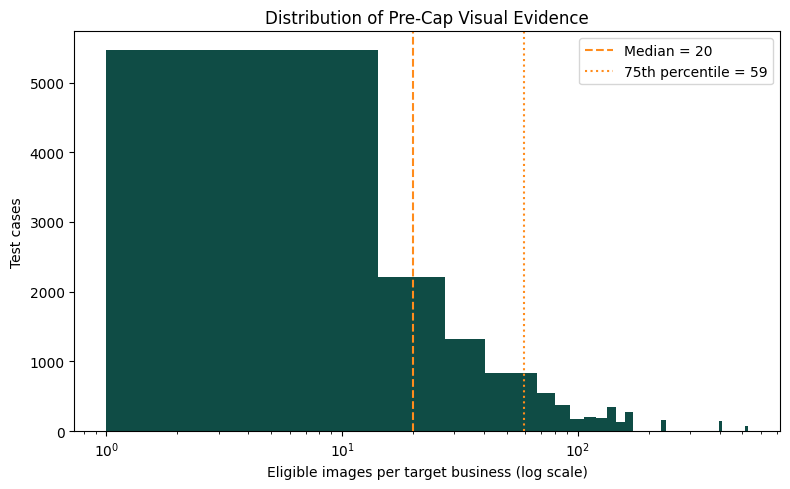

In [19]:
median_images = (
    visual_cases[
        "eligible_image_count_raw"
    ].median()
)

p75_images = (
    visual_cases[
        "eligible_image_count_raw"
    ].quantile(0.75)
)

p95_images = (
    visual_cases[
        "eligible_image_count_raw"
    ].quantile(0.95)
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.hist(
    visual_cases[
        "eligible_image_count_raw"
    ],
    bins=40,
    color=TEAL
)


ax.set_xscale(
    "log"
)


ax.axvline(
    median_images,
    linestyle="--",
    linewidth=1.5,
    color=TANGERINE,
    label=f"Median = {median_images:.0f}"
)


ax.axvline(
    p75_images,
    linestyle=":",
    linewidth=1.5,
    color=TANGERINE,
    label=f"75th percentile = {p75_images:.0f}"
)


ax.set_xlabel(
    "Eligible images per target business (log scale)"
)

ax.set_ylabel(
    "Test cases"
)

ax.set_title(
    "Distribution of Pre-Cap Visual Evidence"
)

ax.legend()


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "raw_visual_evidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

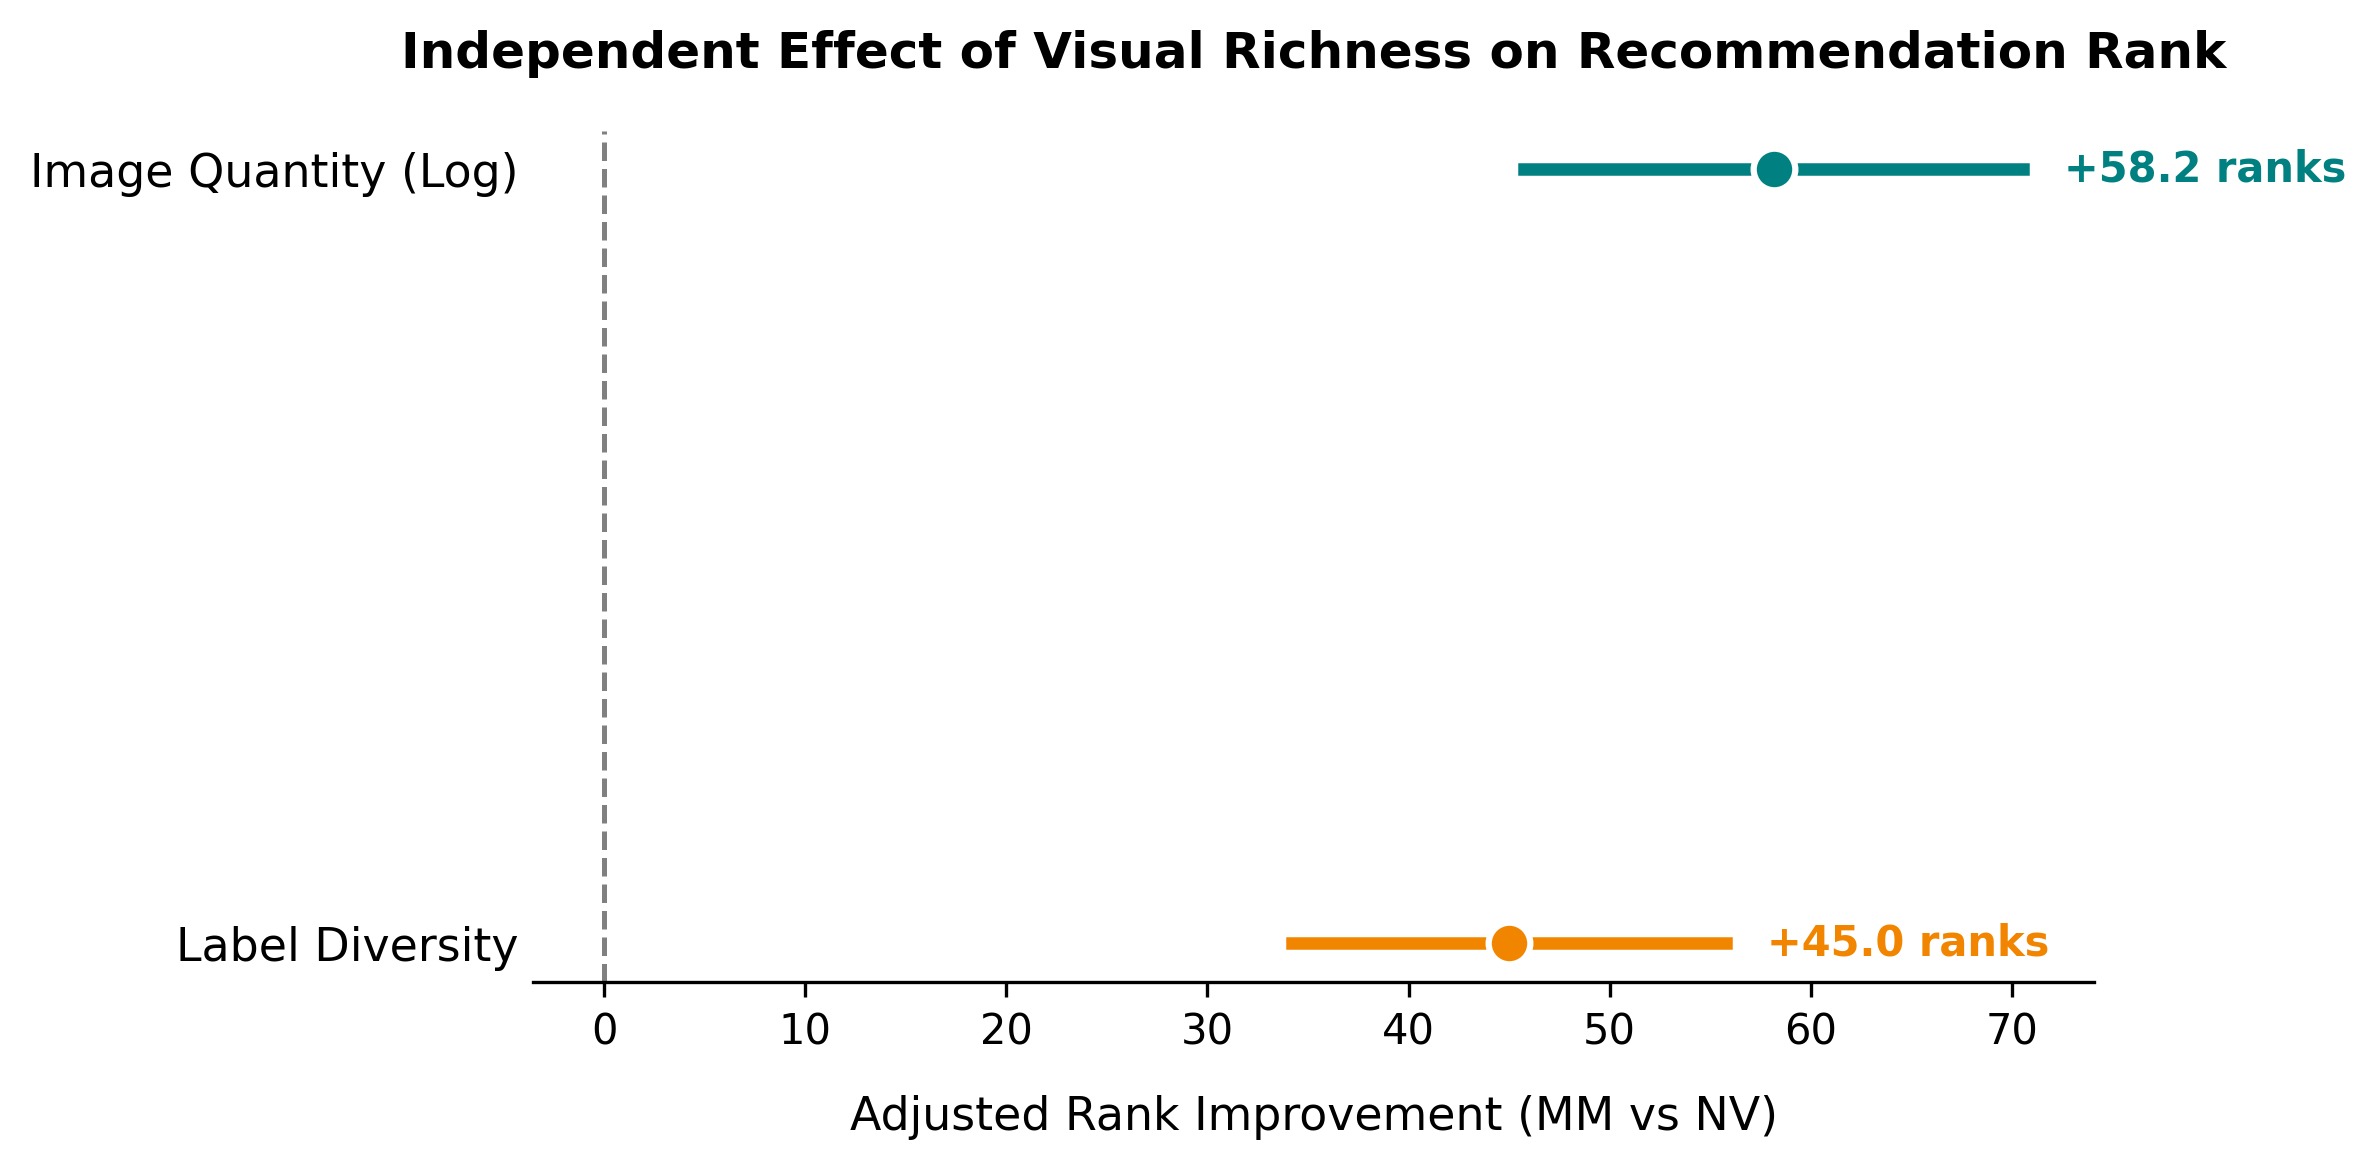

In [20]:
# --------------------------------------------------
# V1.0 — Adjusted Visual Effects Coefficient Plot
# --------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

def plot_adjusted_visual_effects(final_model_dir):
    # Load the adjusted rank effects
    df = pd.read_csv(final_model_dir / "rq3_adjusted_rank_visual_effects.csv")
    
    # Map term names for clean display
    term_mapping = {
        "z_log_raw_image_count": "Image Quantity (Log)",
        "z_eligible_label_diversity_raw": "Label Diversity"
    }
    df["display_term"] = df["term"].map(term_mapping)
    
    # Colors
    teal = "#008080"
    tangerine = "#F28500"
    
    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    
    # Draw the null hypothesis line
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.2, zorder=1)
    
    # Plot each coefficient
    for idx, row in df.iterrows():
        y_pos = len(df) - idx  # Reverse order for top-down display
        color = teal if "Quantity" in row["display_term"] else tangerine
        
        # Error bar (95% CI)
        ax.plot(
            [row["CI_95_lower"], row["CI_95_upper"]], 
            [y_pos, y_pos], 
            color=color, 
            linewidth=3, 
            zorder=2
        )
        
        # Point estimate
        ax.plot(
            row["coefficient"], 
            y_pos, 
            marker='o', 
            markersize=10, 
            color=color, 
            markeredgecolor='white',
            markeredgewidth=1.5,
            zorder=3
        )
        
        # Data labels
        ax.text(
            row["CI_95_upper"] + 2, 
            y_pos, 
            f"+{row['coefficient']:.1f} ranks", 
            va='center', 
            fontsize=10, 
            fontweight='bold', 
            color=color
        )

    # Formatting
    ax.set_yticks([len(df) - i for i in range(len(df))])
    ax.set_yticklabels(df["display_term"], fontsize=11, fontweight='500')
    ax.set_xlabel("Adjusted Rank Improvement (MM vs NV)", fontsize=11, labelpad=10)
    ax.set_title("Independent Effect of Visual Richness on Recommendation Rank", 
                 fontsize=12, fontweight='bold', pad=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_adjusted_visual_effects(final_model_dir)

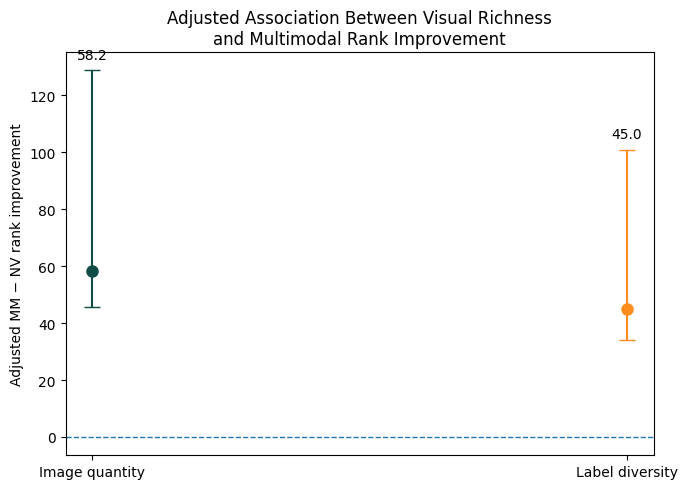

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


rank_effects = pd.read_csv(
    final_model_dir
    /
    "rq3_adjusted_rank_visual_effects.csv"
)


plot_order = [
    "Image quantity",
    "Label diversity"
]


rank_effects[
    "model"
] = pd.Categorical(
    rank_effects[
        "model"
    ],
    categories=plot_order,
    ordered=True
)


rank_effects = (
    rank_effects
    .sort_values(
        "model"
    )
    .reset_index(
        drop=True
    )
)


effects = (
    rank_effects[
        "coefficient"
    ].to_numpy()
)


lower = (
    effects
    -
    rank_effects[
        "CI_95_lower"
    ].to_numpy()
)


upper = (
    rank_effects[
        "CI_95_upper"
    ].to_numpy()
)


x = np.arange(
    len(
        rank_effects
    )
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)


colors = [
    TEAL,
    TANGERINE
]


for i in range(
    len(
        rank_effects
    )
):

    ax.errorbar(
        x[i],
        effects[i],
        yerr=np.array([
            [lower[i]],
            [upper[i]]
        ]),
        fmt="o",
        capsize=6,
        markersize=8,
        color=colors[i]
    )


    ax.text(
        x[i],
        effects[i] + upper[i] + 3,
        f"{effects[i]:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    [
        "Image quantity",
        "Label diversity"
    ]
)


ax.set_ylabel(
    "Adjusted MM − NV rank improvement"
)


ax.set_title(
    "Adjusted Association Between Visual Richness\nand Multimodal Rank Improvement"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "adjusted_visual_richness_rank_effects.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

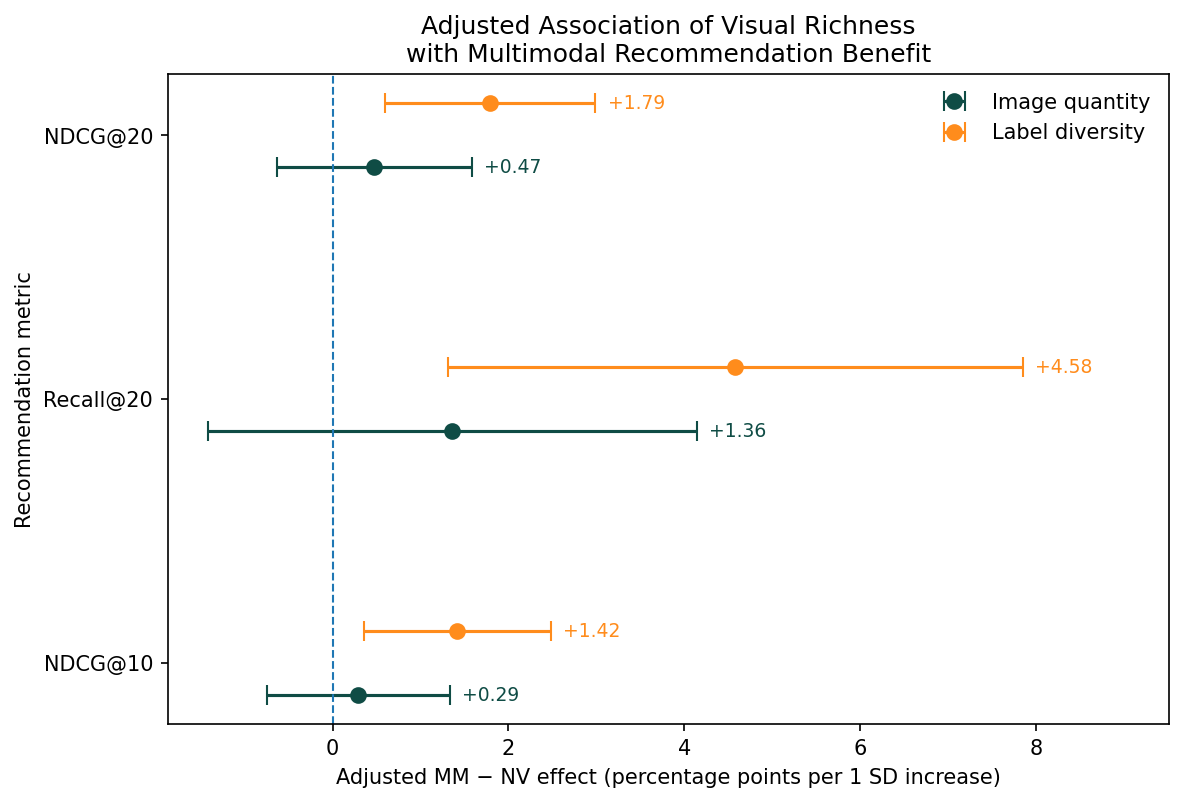

In [ ]:
# --------------------------------------------------
# G7.8 visualisation:
# Adjusted visual-richness effects on top-K outcomes
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


topk_effects = pd.read_csv(
    final_model_dir
    /
    "rq3_clustered_topk_visual_effects.csv"
)


# Cleaner report labels
outcome_labels = {
    "delta_NDCG@10": "NDCG@10",
    "delta_Recall@20": "Recall@20",
    "delta_NDCG@20": "NDCG@20"
}


outcome_order = [
    "delta_NDCG@10",
    "delta_Recall@20",
    "delta_NDCG@20"
]


topk_effects["outcome_label"] = (
    topk_effects["outcome"]
    .map(outcome_labels)
)


# Convert metric units to percentage points
for column in [
    "coefficient",
    "CI_95_lower",
    "CI_95_upper"
]:
    topk_effects[
        f"{column}_pp"
    ] = (
        topk_effects[column]
        * 100
    )


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


y_base = np.arange(
    len(outcome_order)
)

offset = 0.12


plot_specs = [
    (
        "Image quantity",
        TEAL,
        -offset
    ),
    (
        "Label diversity",
        TANGERINE,
        offset
    )
]


for model_name, colour, y_offset in plot_specs:

    subset = (
        topk_effects[
            topk_effects["model"]
            ==
            model_name
        ]
        .set_index("outcome")
        .loc[outcome_order]
        .reset_index()
    )


    effects = (
        subset[
            "coefficient_pp"
        ]
        .to_numpy()
    )


    lower_errors = (
        effects
        -
        subset[
            "CI_95_lower_pp"
        ].to_numpy()
    )


    upper_errors = (
        subset[
            "CI_95_upper_pp"
        ].to_numpy()
        -
        effects
    )


    y = (
        y_base
        +
        y_offset
    )


    ax.errorbar(
        effects,
        y,
        xerr=[
            lower_errors,
            upper_errors
        ],
        fmt="o",
        markersize=7,
        capsize=5,
        linewidth=1.5,
        color=colour,
        label=model_name
    )


    # Keep coefficient labels beyond the full confidence interval.
    # Point-based padding stays consistent across axis scales and export DPI.
    for effect, upper_ci, y_position in zip(
        effects,
        subset["CI_95_upper_pp"].to_numpy(),
        y
    ):
        ax.annotate(
            f"{effect:+.2f}",
            xy=(upper_ci, y_position),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=9,
            color=colour
        )


# Reserve space for the labels after the longest confidence interval.
ci_min = min(0.0, topk_effects["CI_95_lower_pp"].min())
ci_max = max(0.0, topk_effects["CI_95_upper_pp"].max())
ci_span = max(ci_max - ci_min, 1.0)
ax.set_xlim(ci_min - 0.05 * ci_span, ci_max + 0.18 * ci_span)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y_base
)


ax.set_yticklabels([
    "NDCG@10",
    "Recall@20",
    "NDCG@20"
])


ax.set_xlabel(
    "Adjusted MM − NV effect "
    "(percentage points per 1 SD increase)"
)


ax.set_ylabel(
    "Recommendation metric"
)


ax.set_title(
    "Adjusted Association of Visual Richness\n"
    "with Multimodal Recommendation Benefit"
)


ax.legend(
    frameon=False
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "adjusted_visual_richness_topk_effects.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

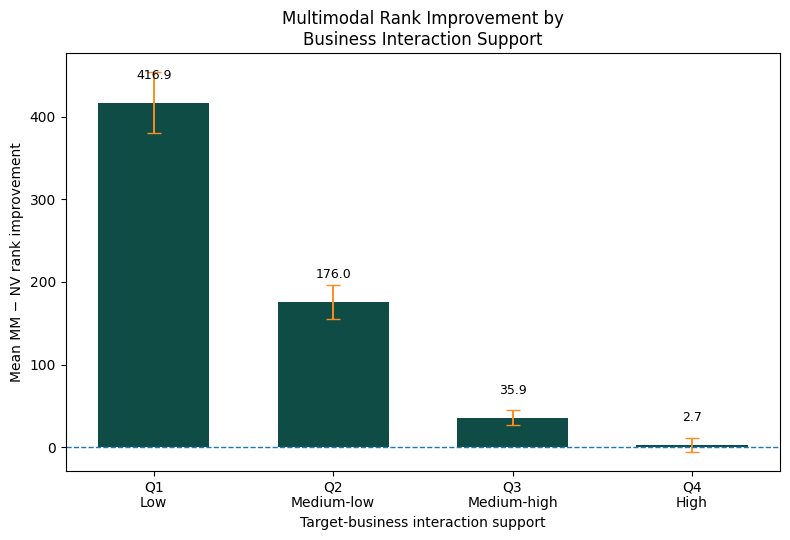

In [23]:
# --------------------------------------------------
# G7.9 visualisation:
# MM−NV rank improvement by interaction support
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


support_effects = pd.read_csv(
    final_model_dir
    /
    "rq3_interaction_support_bootstrap.csv"
)


rank_support = (
    support_effects.loc[
        support_effects["outcome"]
        ==
        "rank_improvement"
    ]
    .copy()
)


support_order = [
    "Q1: Low",
    "Q2: Medium-low",
    "Q3: Medium-high",
    "Q4: High"
]


rank_support["support_group"] = pd.Categorical(
    rank_support["support_group"],
    categories=support_order,
    ordered=True
)


rank_support = (
    rank_support
    .sort_values("support_group")
    .reset_index(drop=True)
)


effects = (
    rank_support["effect"]
    .to_numpy()
)


lower_errors = (
    effects
    -
    rank_support["CI_95_lower"]
    .to_numpy()
)


upper_errors = (
    rank_support["CI_95_upper"]
    .to_numpy()
    -
    effects
)


x = np.arange(
    len(rank_support)
)


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


bars = ax.bar(
    x,
    effects,
    color=TEAL,
    width=0.62
)


ax.errorbar(
    x,
    effects,
    yerr=[
        lower_errors,
        upper_errors
    ],
    fmt="none",
    capsize=5,
    linewidth=1.4,
    color=TANGERINE
)


ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}"
        for value in effects
    ],
    padding=15,
    fontsize=9
)


ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_xticks(x)

ax.set_xticklabels([
    "Q1\nLow",
    "Q2\nMedium-low",
    "Q3\nMedium-high",
    "Q4\nHigh"
])


ax.set_xlabel(
    "Target-business interaction support"
)

ax.set_ylabel(
    "Mean MM − NV rank improvement"
)

ax.set_title(
    "Multimodal Rank Improvement by\n"
    "Business Interaction Support"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "rank_improvement_by_interaction_support.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

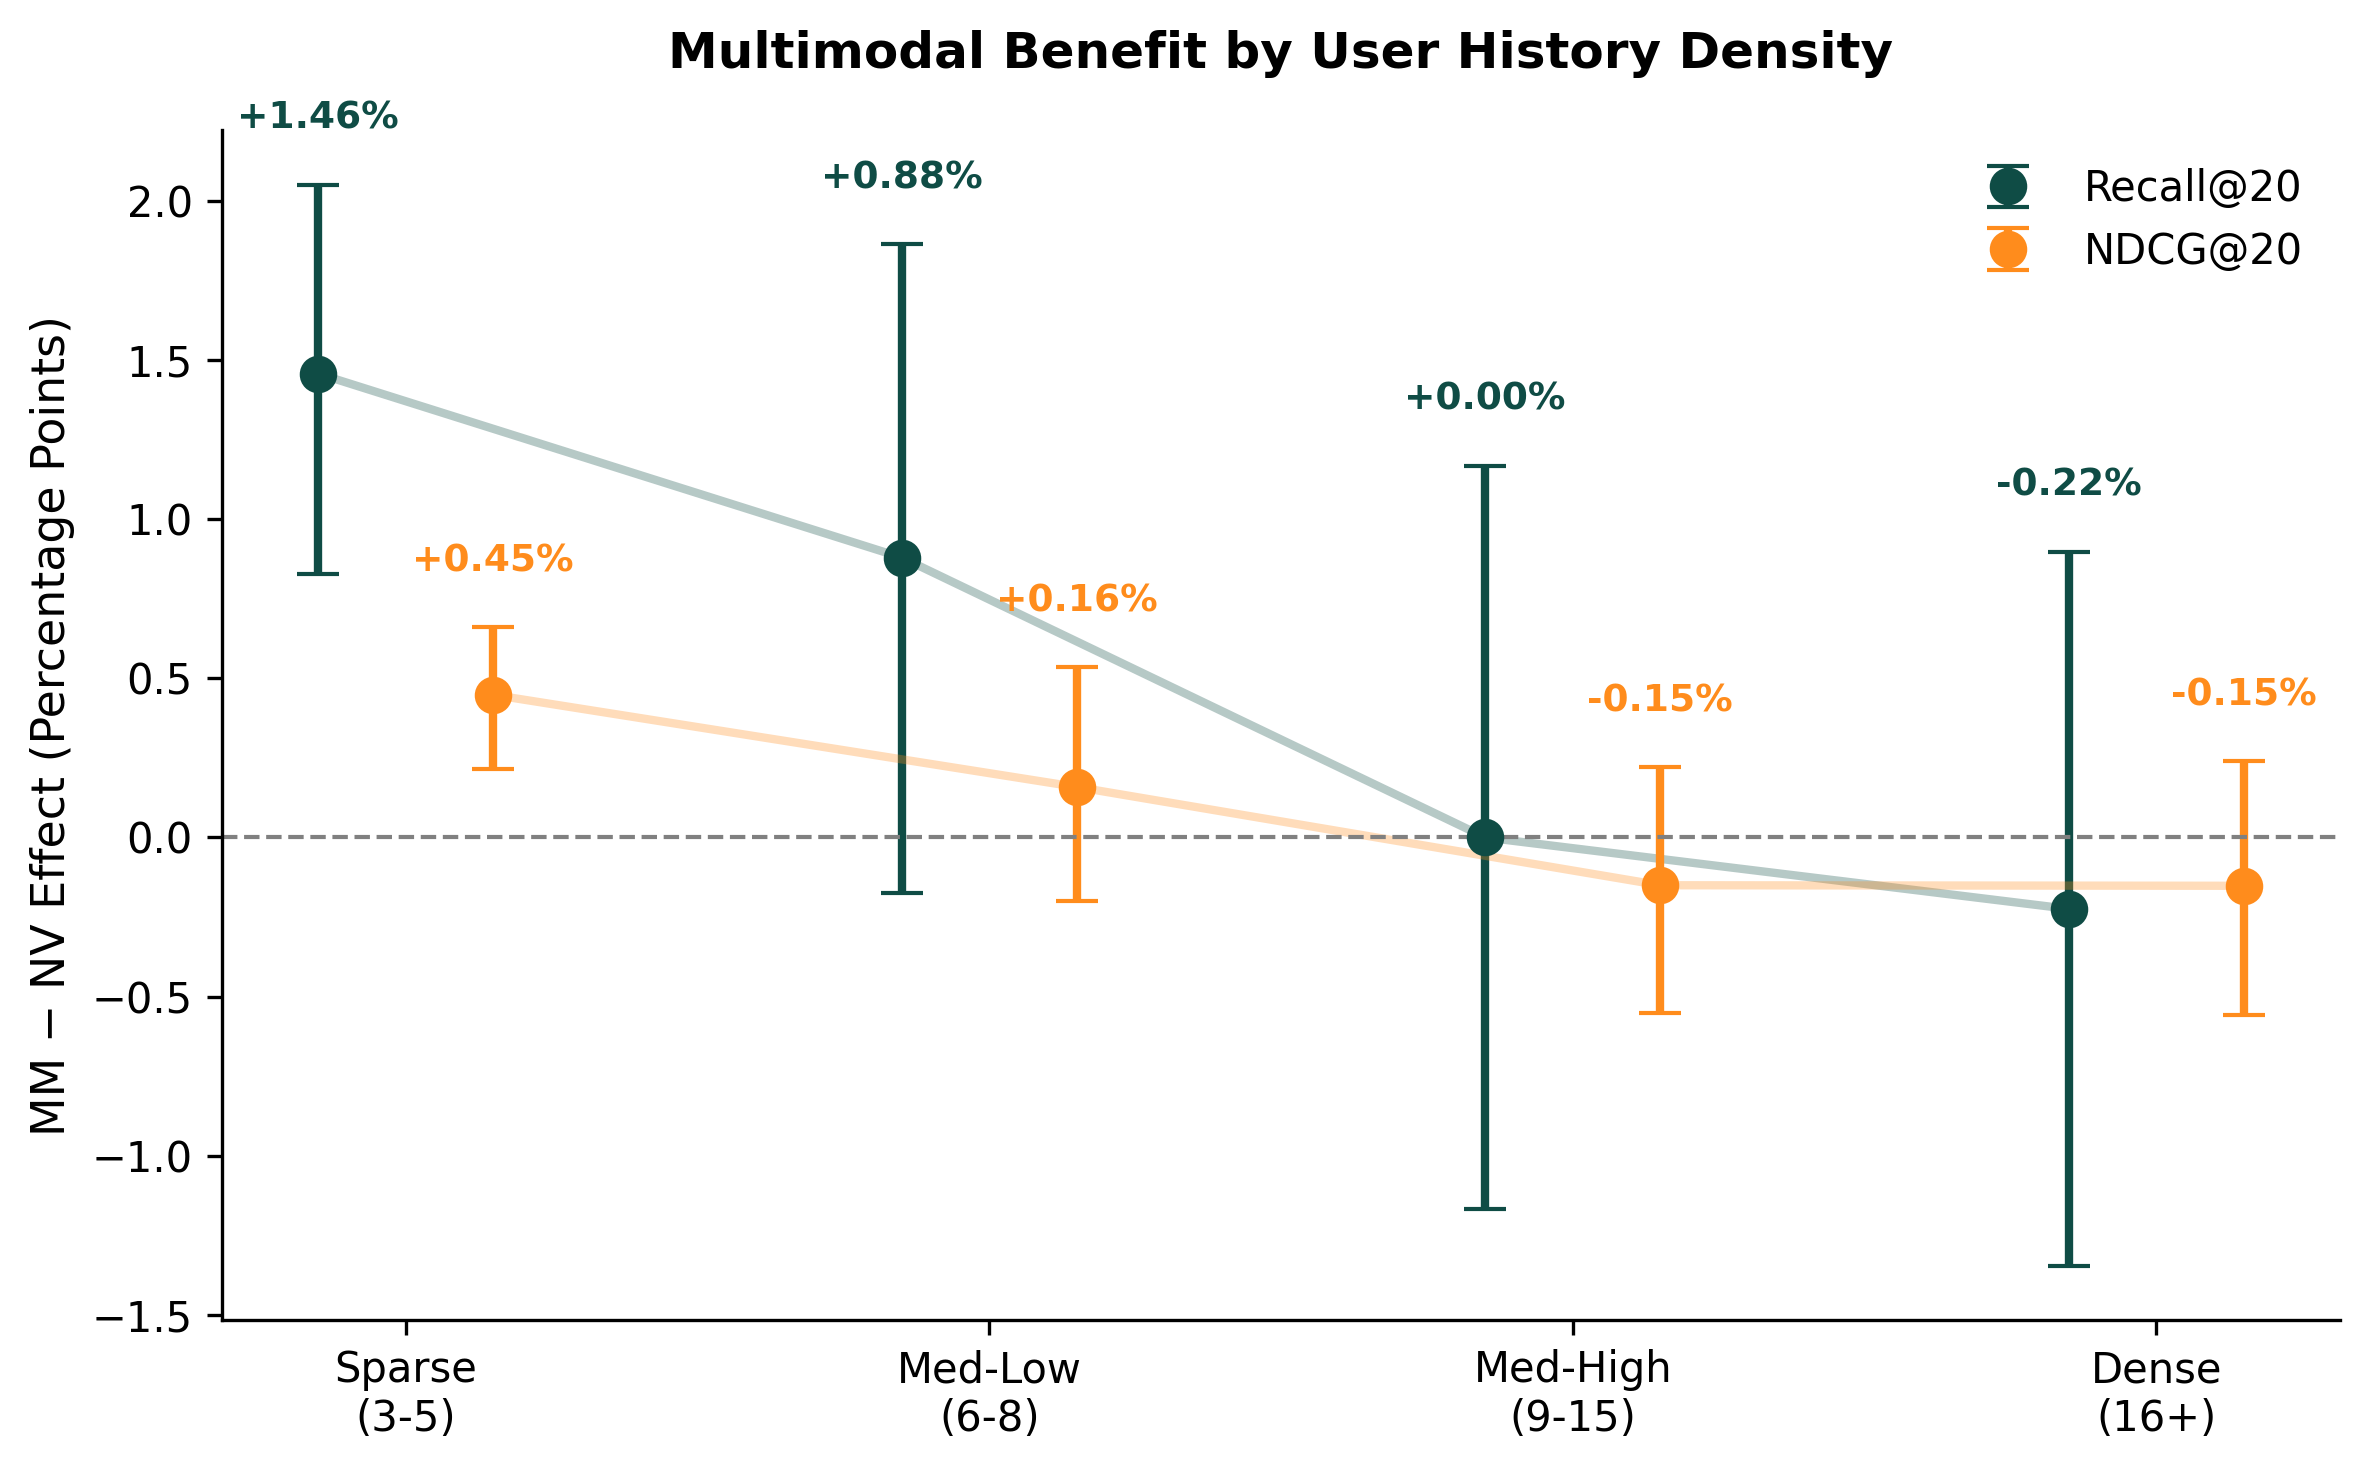

In [24]:
# --------------------------------------------------
# V2.0 — User-History Gradient Plot
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_user_history_gradient(final_model_dir, figure_dir):
    df = pd.read_csv(final_model_dir / "rq3_user_history_bootstrap.csv")
    
    # Filter for the two key metrics and convert to percentages
    metrics = ["delta_Recall@20", "delta_NDCG@20"]
    plot_df = df[df["outcome"].isin(metrics)].copy()
    
    for col in ["effect", "CI_95_lower", "CI_95_upper"]:
        plot_df[col] = plot_df[col] * 100
        
    TEAL = "#0F4C45"
    TANGERINE = "#FF8C1C"
    
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    
    x_labels = ["Sparse\n(3-5)", "Med-Low\n(6-8)", "Med-High\n(9-15)", "Dense\n(16+)"]
    x_pos = np.arange(len(x_labels))
    
    # Offset for side-by-side plotting
    offset = 0.15
    
    for i, (metric, color, label) in enumerate([
        ("delta_Recall@20", TEAL, "Recall@20"),
        ("delta_NDCG@20", TANGERINE, "NDCG@20")
    ]):
        metric_data = plot_df[plot_df["outcome"] == metric]
        
        y = metric_data["effect"].values
        err_lower = y - metric_data["CI_95_lower"].values
        err_upper = metric_data["CI_95_upper"].values - y
        
        x_shifted = x_pos + (offset if i == 1 else -offset)
        
        # Plot lines to show the gradient
        ax.plot(x_shifted, y, color=color, alpha=0.3, linewidth=2)
        
        # Plot points and error bars
        ax.errorbar(
            x_shifted, y, yerr=[err_lower, err_upper],
            fmt='o', color=color, capsize=5, markersize=8, label=label, linewidth=2
        )
        
        # Data labels
        for idx, val in enumerate(y):
            ax.text(x_shifted[idx], val + err_upper[idx] + 0.15, 
                    f"{val:+.2f}%", ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("MM − NV Effect (Percentage Points)", fontsize=11)
    ax.set_title("Multimodal Benefit by User History Density", fontsize=12, fontweight='bold', pad=15)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend(frameon=False, loc='upper right')
    
    plt.tight_layout()
    fig.savefig(figure_dir / "user_history_multimodal_gradient.png")
    plt.show()

plot_user_history_gradient(final_model_dir, figure_dir)

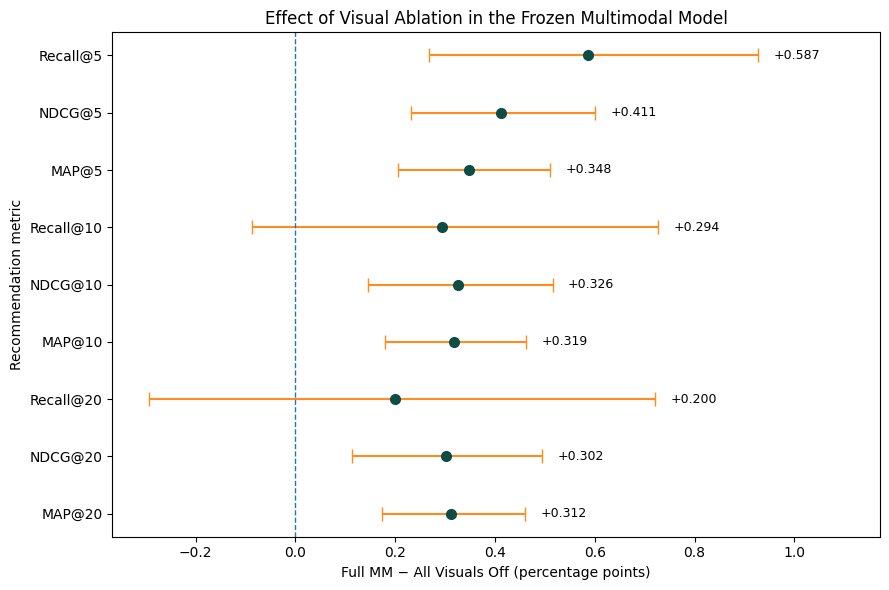

In [25]:
# --------------------------------------------------
# K3 visualisation:
# Frozen-MM visual ablation effects with 95% CI
# Improved label placement
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


ablation_effects = pd.read_csv(
    final_model_dir
    /
    "explanations"
    /
    "k3_catalogue_visual_ablation_bootstrap.csv"
)


# Convert effects to percentage points
for column in [
    "full_minus_all_off",
    "CI_95_lower",
    "CI_95_upper"
]:

    ablation_effects[
        f"{column}_pp"
    ] = (
        ablation_effects[column]
        *
        100
    )


metric_order = [
    "Recall@5",
    "NDCG@5",
    "MAP@5",
    "Recall@10",
    "NDCG@10",
    "MAP@10",
    "Recall@20",
    "NDCG@20",
    "MAP@20"
]


ablation_effects["metric"] = pd.Categorical(
    ablation_effects["metric"],
    categories=metric_order,
    ordered=True
)


ablation_effects = (
    ablation_effects
    .sort_values("metric")
    .reset_index(drop=True)
)


effects = (
    ablation_effects[
        "full_minus_all_off_pp"
    ]
    .to_numpy()
)


ci_lower = (
    ablation_effects[
        "CI_95_lower_pp"
    ]
    .to_numpy()
)


ci_upper = (
    ablation_effects[
        "CI_95_upper_pp"
    ]
    .to_numpy()
)


lower_errors = (
    effects
    -
    ci_lower
)


upper_errors = (
    ci_upper
    -
    effects
)


y = np.arange(
    len(ablation_effects)
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.errorbar(
    effects,
    y,
    xerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    markersize=7,
    capsize=5,
    linewidth=1.5,
    color=TEAL,
    ecolor=TANGERINE
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


# --------------------------------------------------
# Put labels AFTER the upper CI endpoint
# --------------------------------------------------

overall_min = (
    ci_lower.min()
)

overall_max = (
    ci_upper.max()
)

plot_range = (
    overall_max
    -
    overall_min
)

label_padding = (
    plot_range
    *
    0.025
)


for effect, upper_ci, y_position in zip(
    effects,
    ci_upper,
    y
):

    ax.text(
        upper_ci
        +
        label_padding,

        y_position,

        f"{effect:+.3f}",

        va="center",
        ha="left",
        fontsize=9,

        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=1.2
        )
    )


# Extra right-side room for annotations
ax.set_xlim(
    overall_min
    -
    plot_range * 0.06,

    overall_max
    +
    plot_range * 0.20
)


ax.set_yticks(y)

ax.set_yticklabels(
    ablation_effects["metric"]
)


ax.invert_yaxis()


ax.set_xlabel(
    "Full MM − All Visuals Off "
    "(percentage points)"
)


ax.set_ylabel(
    "Recommendation metric"
)


ax.set_title(
    "Effect of Visual Ablation in the Frozen Multimodal Model"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "k3_frozen_mm_visual_ablation_effects.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

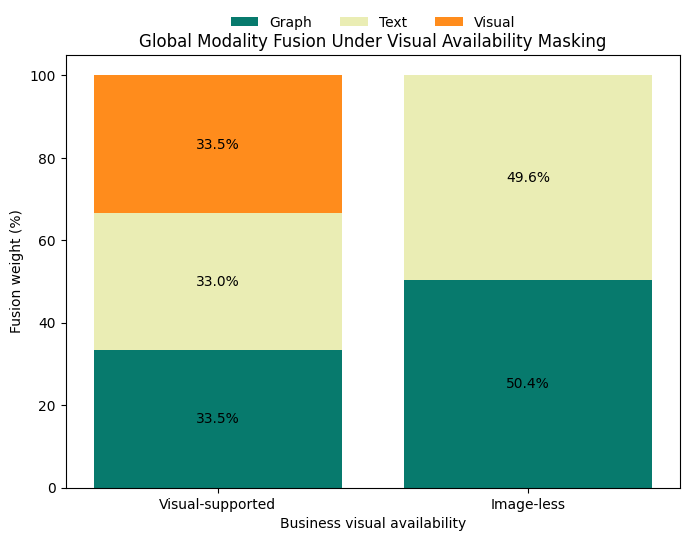

In [26]:
# --------------------------------------------------
# K2 visualisation:
# Modality fusion under visual availability masking
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#077a6d"
TANGERINE = "#FF8C1C"
NEUTRAL = "#eaedb4"


fusion = pd.read_csv(
    final_model_dir
    /
    "explanations"
    /
    "k2_global_fusion_summary.csv"
)


conditions = [
    "Visual-supported",
    "Image-less"
]


graph_values = np.array([
    fusion.loc[
        fusion["modality"] == "Graph",
        "visual_supported_weight"
    ].iloc[0],

    fusion.loc[
        fusion["modality"] == "Graph",
        "image_less_weight"
    ].iloc[0]
]) * 100


text_values = np.array([
    fusion.loc[
        fusion["modality"] == "Text",
        "visual_supported_weight"
    ].iloc[0],

    fusion.loc[
        fusion["modality"] == "Text",
        "image_less_weight"
    ].iloc[0]
]) * 100


visual_values = np.array([
    fusion.loc[
        fusion["modality"] == "Visual",
        "visual_supported_weight"
    ].iloc[0],

    fusion.loc[
        fusion["modality"] == "Visual",
        "image_less_weight"
    ].iloc[0]
]) * 100


x = np.arange(
    len(conditions)
)


fig, ax = plt.subplots(
    figsize=(7, 5.5)
)


graph_bars = ax.bar(
    x,
    graph_values,
    label="Graph",
    color=TEAL
)


text_bars = ax.bar(
    x,
    text_values,
    bottom=graph_values,
    label="Text",
    color=NEUTRAL
)


visual_bars = ax.bar(
    x,
    visual_values,
    bottom=(
        graph_values
        +
        text_values
    ),
    label="Visual",
    color=TANGERINE
)


# Segment labels
for i in range(
    len(conditions)
):

    # Graph
    ax.text(
        x[i],
        graph_values[i] / 2,
        f"{graph_values[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=10
    )


    # Text
    ax.text(
        x[i],
        graph_values[i]
        +
        text_values[i] / 2,

        f"{text_values[i]:.1f}%",

        ha="center",
        va="center",
        fontsize=10
    )


    # Visual — label only when non-zero
    if visual_values[i] > 0:

        ax.text(
            x[i],
            graph_values[i]
            +
            text_values[i]
            +
            visual_values[i] / 2,

            f"{visual_values[i]:.1f}%",

            ha="center",
            va="center",
            fontsize=10
        )


ax.set_xticks(x)

ax.set_xticklabels(
    conditions
)


ax.set_ylim(
    0,
    105
)


ax.set_ylabel(
    "Fusion weight (%)"
)


ax.set_xlabel(
    "Business visual availability"
)


ax.set_title(
    "Global Modality Fusion Under Visual Availability Masking"
)


ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "k2_global_modality_masking_stack.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

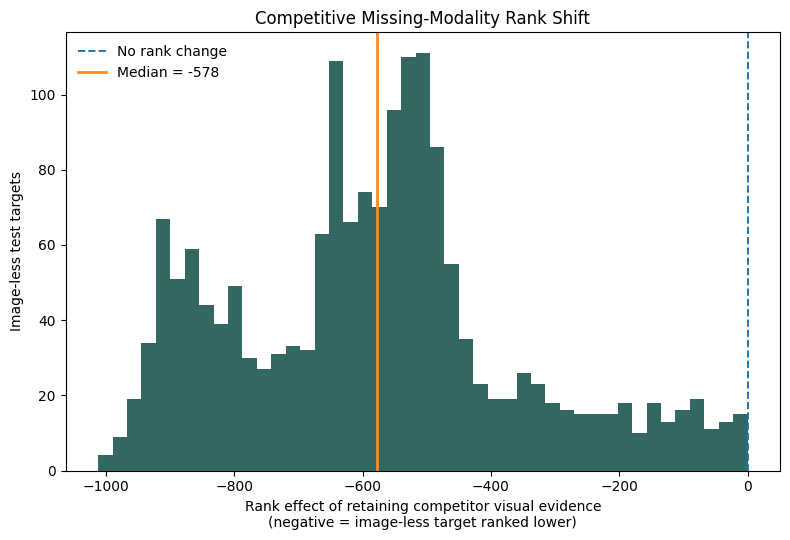

In [27]:
# --------------------------------------------------
# K3 visualisation:
# Competitive missing-modality rank shift
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"


rq3_plot_data = pd.read_parquet(
    final_model_dir
    /
    "rq3_paired_test_analysis.parquet"
)


image_less_cases = (
    rq3_plot_data.loc[
        ~rq3_plot_data[
            "target_has_visual"
        ].astype(bool)
    ]
    .copy()
)


image_less_cases[
    "competitive_rank_effect"
] = (
    image_less_cases[
        "mm_all_visual_off_rank"
    ]
    -
    image_less_cases[
        "mm_rank"
    ]
)


effects = (
    image_less_cases[
        "competitive_rank_effect"
    ]
)


median_effect = (
    effects.median()
)


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


ax.hist(
    effects,
    bins=45,
    color=TEAL,
    alpha=0.85
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.4,
    label="No rank change"
)


ax.axvline(
    median_effect,
    linestyle="-",
    linewidth=2,
    color=TANGERINE,
    label=f"Median = {median_effect:.0f}"
)


ax.set_xlabel(
    "Rank effect of retaining competitor visual evidence\n"
    "(negative = image-less target ranked lower)"
)


ax.set_ylabel(
    "Image-less test targets"
)


ax.set_title(
    "Competitive Missing-Modality Rank Shift"
)


ax.legend(
    frameon=False
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "k3_image_less_competitive_rank_shift.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

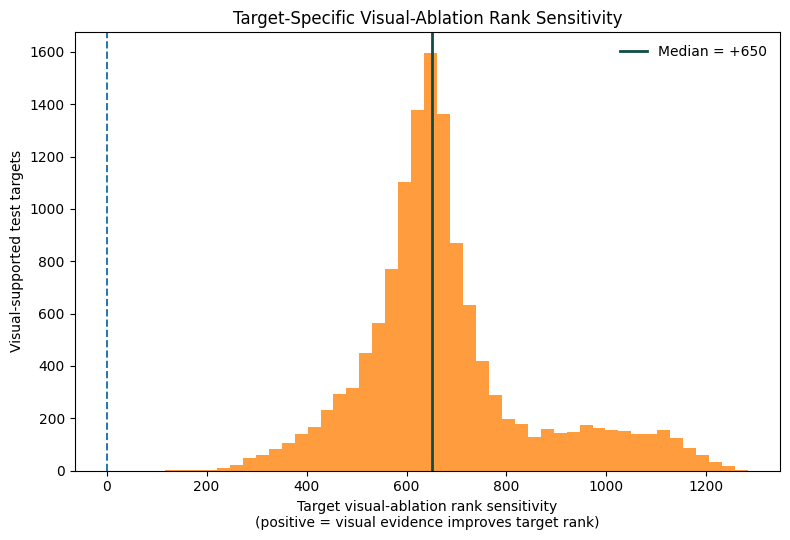

In [28]:
# --------------------------------------------------
# K3 supporting visualisation:
# Target-specific visual-ablation rank sensitivity
# --------------------------------------------------

visual_cases = (
    rq3_plot_data.loc[
        rq3_plot_data[
            "target_has_visual"
        ].astype(bool)
    ]
    .copy()
)


rank_gain = (
    visual_cases[
        "target_visual_rank_gain"
    ]
)


median_gain = (
    rank_gain.median()
)


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


ax.hist(
    rank_gain,
    bins=45,
    color=TANGERINE,
    alpha=0.85
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.4
)


ax.axvline(
    median_gain,
    linestyle="-",
    linewidth=2,
    color=TEAL,
    label=f"Median = +{median_gain:.0f}"
)


ax.set_xlabel(
    "Target visual-ablation rank sensitivity\n"
    "(positive = visual evidence improves target rank)"
)


ax.set_ylabel(
    "Visual-supported test targets"
)


ax.set_title(
    "Target-Specific Visual-Ablation Rank Sensitivity"
)


ax.legend(
    frameon=False
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "k3_target_visual_rank_sensitivity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

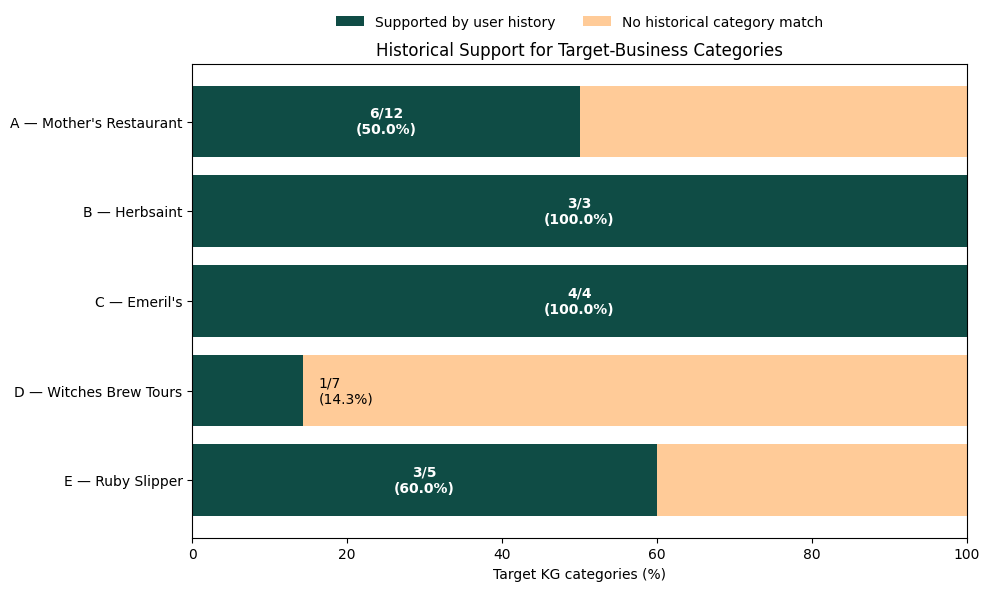

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"   # assuming this is the intended tangerine


case_evidence = pd.read_csv(
    final_model_dir / "explanations" / "k5_case_behaviour_summary.csv"
)

case_labels = [
    "A — Mother's Restaurant",
    "B — Herbsaint",
    "C — Emeril's",
    "D — Witches Brew Tours",
    "E — Ruby Slipper"
]

supported = (
    case_evidence["target_category_support_fraction"].to_numpy() * 100
)

unsupported = 100 - supported

supported_counts = (
    case_evidence["target_categories_supported_by_history"]
    .astype(int)
    .to_numpy()
)

total_counts = (
    case_evidence["target_category_count"]
    .astype(int)
    .to_numpy()
)

y = np.arange(len(case_labels))

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    y,
    supported,
    color=TEAL,
    label="Supported by user history"
)

ax.barh(
    y,
    unsupported,
    left=supported,
    color=TANGERINE,
    alpha=0.45,
    label="No historical category match"
)

for i, (pct, count, total) in enumerate(zip(supported, supported_counts, total_counts)):
    label = f"{count}/{total}\n({pct:.1f}%)"

    # If supported segment is wide enough, place label inside the teal segment
    if pct >= 18:
        ax.text(
            pct / 2,
            i,
            label,
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            fontweight="bold"
        )
    else:
        # Move label just outside when the segment is too narrow
        ax.text(
            pct + 2,
            i,
            label,
            ha="left",
            va="center",
            fontsize=10,
            color="black",
            # bbox=dict(edgecolor="none", alpha=0.1, pad=1.5)
        )

ax.set_yticks(y)
ax.set_yticklabels(case_labels)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Target KG categories (%)")
ax.set_title("Historical Support for Target-Business Categories")
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    ncol=2
)

plt.tight_layout()

fig.savefig(
    figure_dir / "k5_target_category_history_support_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

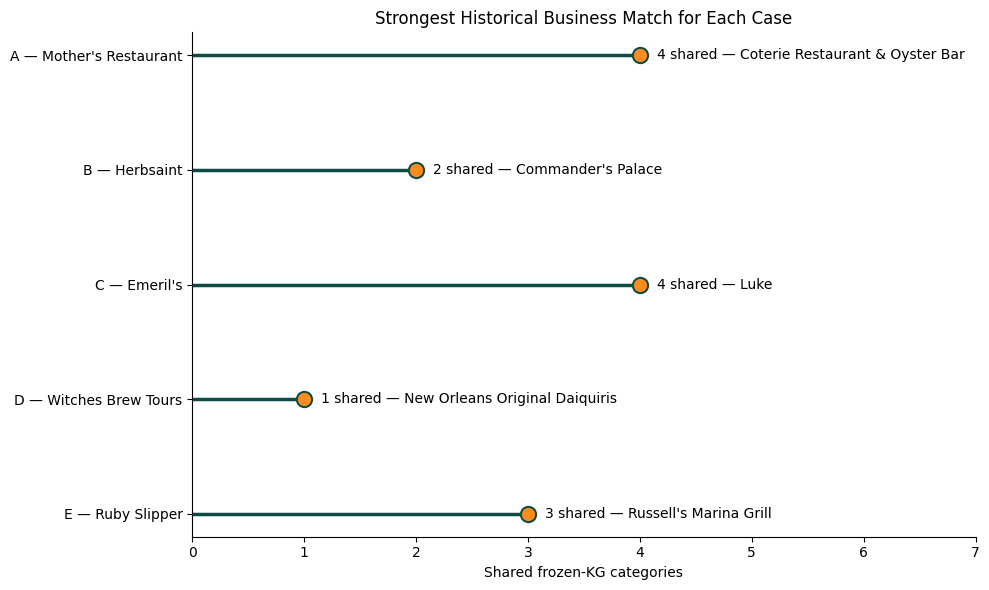

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"

history_matches = pd.read_csv(
    final_model_dir / "explanations" / "k5_case_matching_training_businesses.csv"
)

strongest_match = (
    history_matches
    .sort_values(
        ["case_type", "shared_category_count", "name"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset=["case_type"], keep="first")
)

case_order = [
    "A — Visual Top-20 Gain",
    "B — High-Diversity Visual Gain",
    "C — Visual Counterexample",
    "D — Image-less Competitive Penalty",
    "E — Sparse-User Visual Gain"
]

case_label_map = {
    "A — Visual Top-20 Gain": "A — Mother's Restaurant",
    "B — High-Diversity Visual Gain": "B — Herbsaint",
    "C — Visual Counterexample": "C — Emeril's",
    "D — Image-less Competitive Penalty": "D — Witches Brew Tours",
    "E — Sparse-User Visual Gain": "E — Ruby Slipper"
}

strongest_match["case_type"] = pd.Categorical(
    strongest_match["case_type"],
    categories=case_order,
    ordered=True
)

strongest_match = (
    strongest_match
    .sort_values("case_type")
    .reset_index(drop=True)
)

case_labels = [
    case_label_map[c] for c in strongest_match["case_type"]
]

values = strongest_match["shared_category_count"].to_numpy()
match_names = strongest_match["name"].tolist()

y = np.arange(len(values))

fig, ax = plt.subplots(figsize=(10, 6))

# stems
for i, v in enumerate(values):
    ax.hlines(
        y=i,
        xmin=0,
        xmax=v,
        color=TEAL,
        linewidth=2.5
    )

# dots
ax.scatter(
    values,
    y,
    s=120,
    color=TANGERINE,
    edgecolor=TEAL,
    linewidth=1.5,
    zorder=3
)

# annotations
for i, (v, name) in enumerate(zip(values, match_names)):
    ax.text(
        v + 0.15,
        i,
        f"{int(v)} shared — {name}",
        va="center",
        fontsize=10
    )

ax.set_yticks(y)
ax.set_yticklabels(case_labels)
ax.invert_yaxis()
ax.set_xlabel("Shared frozen-KG categories")
ax.set_title("Strongest Historical Business Match for Each Case")
ax.set_xlim(0, max(values) + 3)

# cleaner appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figure_dir / "k5_strongest_historical_business_match_lollipop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"

# adjust this if your folder name is different
final_model_dir = Path("processed_data/new_orleans_final_model")
figure_dir = final_model_dir / "figures"
explanation_dir = final_model_dir / "explanations"

figure_dir.mkdir(parents=True, exist_ok=True)

In [32]:
# --------------------------------------------------
# K6 visualisation:
# RQ4 qualitative evidence-consistency heatmap
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


TEAL = "#0F4C45"
TANGERINE = "#FF8C1C"

HETEROGENEITY = "#8A8A8A"
NOT_PRIMARY = "#EEEEEE"


# --------------------------------------------------
# Qualitative evidence matrix
# --------------------------------------------------

rq4_heatmap = pd.DataFrame(
    {
        "K2 — Global fusion": [
            "Qualifies",
            "Supports",
            "Not primary",
            "Not primary",
            "Not primary",
            "Not primary",
            "Supports",
            "Not primary"
        ],

        "K3 — Perturbation": [
            "Supports",
            "Qualifies",
            "Not primary",
            "Not primary",
            "Not primary",
            "Not primary",
            "Supports",
            "Qualifies"
        ],

        "K5 — Case evidence": [
            "Heterogeneity",
            "Not primary",
            "Qualifies",
            "Supports",
            "Heterogeneity",
            "Qualifies",
            "Supports",
            "Heterogeneity"
        ]
    },

    index=[
        "Overall visual effect",
        "Global modality balance",
        "Visual label diversity",
        "Image quantity",
        "User-history sparsity",
        "Business interaction support",
        "Missing visual modality",
        "Evidence availability vs success"
    ]
)


rq4_heatmap

,K2 — Global fusion,K3 — Perturbation,K5 — Case evidence
Overall visual effect,Qualifies,Supports,Heterogeneity
Global modality balance,Supports,Qualifies,Not primary
Visual label diversity,Not primary,Not primary,Qualifies
Image quantity,Not primary,Not primary,Supports
User-history sparsity,Not primary,Not primary,Heterogeneity
Business interaction support,Not primary,Not primary,Qualifies
Missing visual modality,Supports,Supports,Supports
Evidence availability vs success,Not primary,Qualifies,Heterogeneity


In [33]:
from pathlib import Path

# --------------------------------------------------
# Correct frozen output paths
# --------------------------------------------------

possible_processed_paths = [
    Path.cwd() / "processed_data",
    Path.cwd().parent / "processed_data",
    Path.cwd().parent.parent / "processed_data"
]

existing_processed_paths = [
    path.resolve()
    for path in possible_processed_paths
    if path.exists()
]

if len(existing_processed_paths) == 0:
    raise FileNotFoundError(
        "Could not locate processed_data."
    )

processed_data_root = existing_processed_paths[0]

final_model_dir = (
    processed_data_root
    /
    "new_orleans_model_outputs"
)

explanation_dir = (
    final_model_dir
    /
    "explanations"
)

figure_dir = (
    final_model_dir
    /
    "figures"
)

explanation_dir.mkdir(
    parents=True,
    exist_ok=True
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Processed data:",
    processed_data_root
)

print(
    "Model outputs:",
    final_model_dir
)

print(
    "Explanation outputs:",
    explanation_dir
)

print(
    "Figure outputs:",
    figure_dir
)

Processed data: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data
Model outputs: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data/new_orleans_model_outputs
Explanation outputs: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data/new_orleans_model_outputs/explanations
Figure outputs: /Users/preye/Downloads/Masters AI:ML/Masters Project/Dataset_exploration/processed_data/new_orleans_model_outputs/figures


In [34]:
rq4_heatmap.to_csv(
    explanation_dir
    /
    "k6_rq4_evidence_heatmap_matrix.csv"
)

In [35]:
# --------------------------------------------------
# Category coding for visualisation only
# --------------------------------------------------

category_code = {
    "Not primary": 0,
    "Heterogeneity": 1,
    "Qualifies": 2,
    "Supports": 3
}


heatmap_numeric = (
    rq4_heatmap
    .replace(
        category_code
    )
    .astype(int)
)


/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_2359/681886714.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(


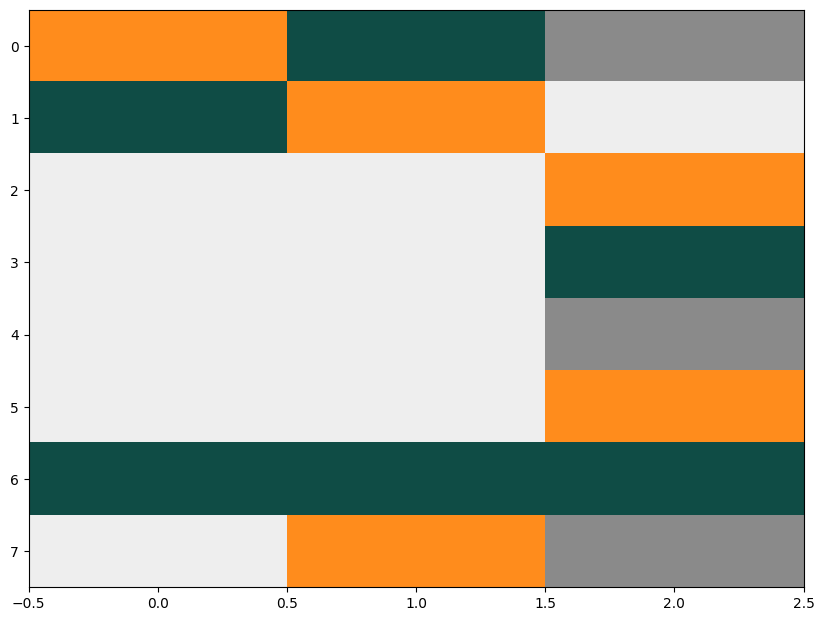

In [36]:
# --------------------------------------------------
# Plot
# --------------------------------------------------

cmap = ListedColormap([
    NOT_PRIMARY,
    HETEROGENEITY,
    TANGERINE,
    TEAL
])


norm = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5,
        2.5,
        3.5
    ],
    cmap.N
)


fig, ax = plt.subplots(
    figsize=(10, 7.5)
)


image = ax.imshow(
    heatmap_numeric.to_numpy(),
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

In [37]:
for row_index in range(
    heatmap_numeric.shape[0]
):

    for column_index in range(
        heatmap_numeric.shape[1]
    ):

        label = (
            rq4_heatmap.iloc[
                row_index,
                column_index
            ]
        )


        numeric_value = (
            heatmap_numeric.iloc[
                row_index,
                column_index
            ]
        )


        # White text on the two darkest categories
        if numeric_value in [
            1,
            3
        ]:

            text_colour = "white"

        else:

            text_colour = "black"


        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=text_colour
        )

In [38]:
ax.set_xticks(
    np.arange(
        len(
            rq4_heatmap.columns
        )
    )
)


ax.set_xticklabels(
    rq4_heatmap.columns,
    fontsize=10
)


ax.set_yticks(
    np.arange(
        len(
            rq4_heatmap.index
        )
    )
)


ax.set_yticklabels(
    rq4_heatmap.index,
    fontsize=10
)


ax.tick_params(
    axis="x",
    bottom=False,
    top=True,
    labelbottom=False,
    labeltop=True,
    pad=8
)


ax.tick_params(
    axis="y",
    length=0
)

In [39]:
ax.set_xticks(
    np.arange(
        -0.5,
        heatmap_numeric.shape[1],
        1
    ),
    minor=True
)


ax.set_yticks(
    np.arange(
        -0.5,
        heatmap_numeric.shape[0],
        1
    ),
    minor=True
)


ax.grid(
    which="minor",
    linewidth=2,
    color="white"
)


ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

In [40]:
legend_items = [

    Patch(
        facecolor=TEAL,
        label="Supports"
    ),

    Patch(
        facecolor=TANGERINE,
        label="Qualifies"
    ),

    Patch(
        facecolor=HETEROGENEITY,
        label="Heterogeneity / counterexample"
    ),

    Patch(
        facecolor=NOT_PRIMARY,
        edgecolor="#CCCCCC",
        label="Not primary evidence"
    )
]


ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.08
    ),
    ncol=2,
    fontsize=9.5
)

In [41]:
ax.set_title(
    "Consistency Between Quantitative Findings and Explanation Evidence",
    fontsize=13,
    pad=55
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "k6_rq4_evidence_consistency_heatmap.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()